# Dynamical Critical Exponents in the 2D Ising Model

Critical slowing down makes equilibrium sampling progressively harder as a continuous transition is approached. At the Onsager point, the integrated autocorrelation time scales as $\tau_{\mathrm{int}} \propto L^z$, so the dynamical critical exponent $z$ measures how quickly the cost of generating statistically independent configurations grows with lattice size [[1]](#Bibliography).

This notebook compares random-site Metropolis dynamics with the Wolff cluster update using the same measurement target as `scripts/ising/measure_z.py`. The central comparison is the slope of $\tau_{\mathrm{int}}(L)$ on log-log axes: Metropolis remains diffusion-limited, while Wolff removes most of the critical slowdown [[2]](#Bibliography).

## Why the slopes differ

Local Metropolis updates move domain walls one spin at a time, so correlations relax diffusively near $T_c$ and the autocorrelation time grows steeply with $L$. Wolff instead flips correlated domains as a single accepted move, matching the scale of the critical fluctuations and flattening the growth of $\tau_{\mathrm{int}}$.

For Wolff it is useful to distinguish cluster-step time from sweep-equivalent time. The plot below reports the measured exponent in cluster-step units; when one rescales by the typical number of spins flipped per cluster, the effective sweep-based exponent is smaller still [[2]](#Bibliography).

## Load or compute data

If the script output `../results/ising/dynamic_exponent_z.npz` is present, the notebook loads it directly. Otherwise it runs a deliberately small inline fallback so the workflow stays self-contained. The fallback is useful for checking the analysis path, but only the script-backed dataset should be treated as a serious estimate of $z$ because the published-quality measurement needs much longer trajectories and careful equilibration [[3]](#Bibliography).

```bash
python scripts/ising/measure_z.py --sizes 16 32 48 64 96 128
```

In [1]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np

from utils.exceptions import ZeroVarianceAutocorrelationError
from utils.physics_helpers import calculate_autocorr

TC_ISING = 2.0 / np.log(1.0 + np.sqrt(2.0))
NPZ_PATH = '../results/ising/dynamic_exponent_z.npz'
PALETTE = {'metro': '#4878CF', 'wolff': '#D65F5F'}


def estimate_tau(update: str, size: int, meas_steps: int, seed: int) -> float:
    from models.ising_model import IsingSimulation
    from utils.system_helpers import convergence_equilibrate

    sim_r = IsingSimulation(size=size, temp=TC_ISING, update=update, init_state='random', seed=seed)
    sim_o = IsingSimulation(size=size, temp=TC_ISING, update=update, init_state='ordered', seed=seed)
    convergence_equilibrate(sim_r, sim_o, chunk_size=100, max_steps=10000)
    mags, _ = sim_r.run(n_steps=meas_steps)

    try:
        _, tau_int = calculate_autocorr(time_series=np.asarray(mags, dtype=float))
    except ZeroVarianceAutocorrelationError:
        tau_int = float('nan')

    return float(tau_int)


if os.path.exists(NPZ_PATH):
    data = np.load(NPZ_PATH)
    L_metro = data['L_metro']
    tau_metro = data['tau_metro']
    L_wolff = data['L_wolff']
    tau_wolff = data['tau_wolff']
    Tc = float(data['Tc'])
    print(
        f'Loaded pre-computed data from {NPZ_PATH}: '
        f'{len(L_metro)} Metropolis points, {len(L_wolff)} Wolff points.'
    )

else:
    print(
        'Pre-computed data not found. Running inline demo '
        '(sizes 16, 24, 32; non-publication-quality).'
)
    sizes = [16, 24, 32]
    L_metro = np.asarray(sizes, dtype=float)
    L_wolff = np.asarray(sizes, dtype=float)
    tau_metro = np.asarray(
        [estimate_tau(update='random', size=size, meas_steps=2500, seed=idx * 100) for idx, size in enumerate(sizes)],
        dtype=float,
    )
    tau_wolff = np.asarray(
        [estimate_tau(update='wolff', size=size, meas_steps=800, seed=idx * 100 + 1) for idx, size in enumerate(sizes)],
        dtype=float,
    )
    Tc = TC_ISING
    print(f'Computed fallback data at T_c = {Tc:.6f} for sizes {sizes}.')

Loaded pre-computed data from ../results/ising/dynamic_exponent_z.npz: 6 Metropolis points, 6 Wolff points.


## Scaling plot

The fit uses the shared `power_fit` helper on the finite points only, then overlays the inferred power law on top of the raw data. The exact numbers depend on whether the notebook loaded the full script output or the smaller fallback dataset, but the qualitative separation between the two algorithms should be stable.

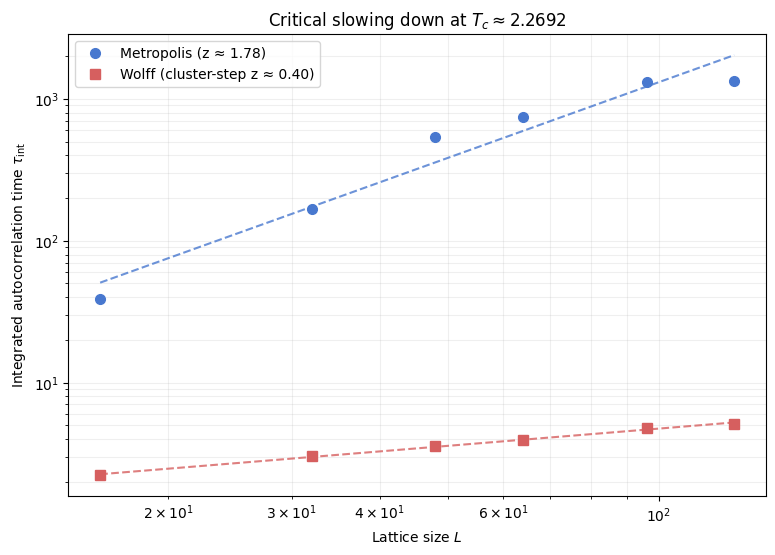

In [2]:
from utils.physics_helpers import power_fit

mask_m = np.isfinite(tau_metro)
mask_w = np.isfinite(tau_wolff)

exponent_m, prefactor_m = power_fit(t_arr=L_metro, y_arr=tau_metro, mask=mask_m)
exponent_w, prefactor_w = power_fit(t_arr=L_wolff, y_arr=tau_wolff, mask=mask_w)

L_fit = np.linspace(min(L_metro.min(), L_wolff.min()), max(L_metro.max(), L_wolff.max()), 200)
tau_fit_m = prefactor_m * L_fit**exponent_m
tau_fit_w = prefactor_w * L_fit**exponent_w

plt.figure(figsize=(9, 6))
plt.loglog(
    L_metro,
    tau_metro,
    'o',
    color=PALETTE['metro'],
    markersize=7,
    label=f'Metropolis (z ≈ {exponent_m:.2f})',
)
plt.loglog(L_fit, tau_fit_m, '--', color=PALETTE['metro'], alpha=0.8)

plt.loglog(
    L_wolff,
    tau_wolff,
    's',
    color=PALETTE['wolff'],
    markersize=7,
    label=f'Wolff (cluster-step z ≈ {exponent_w:.2f})',
)
plt.loglog(L_fit, tau_fit_w, '--', color=PALETTE['wolff'], alpha=0.8)

plt.xlabel('Lattice size $L$')
plt.ylabel(r'Integrated autocorrelation time $\tau_{\mathrm{int}}$')
plt.title(fr'Critical slowing down at $T_c \approx {Tc:.4f}$')
plt.grid(True, which='both', alpha=0.2)
plt.legend()
plt.show()

## Reading the result

The Metropolis fit should remain close to the textbook local-dynamics result $z \approx 2$, reflecting the diffusive cost of decorrelating large critical domains. The Wolff fit is much flatter because a single accepted cluster flip already reorganizes a macroscopic region near $T_c$. Even when the fallback dataset shifts the fitted values slightly, the gap in slope is the main physical result: cluster updates change the scaling law, not just the prefactor.

## Scientific implication

The Wolff algorithm is the right tool for equilibrium sampling at criticality because it suppresses critical slowing down without changing the target Boltzmann distribution. That does not make it a faithful model of physical time evolution. When the goal is non-equilibrium kinetics or physically interpretable dynamics, local updates remain the correct choice even though they are slower.

## Bibliography

[[1]](#Bibliography) L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review*, vol. 65, no. 3-4, pp. 117–149, 1944. [APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[[2]](#Bibliography) U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361–364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[[3]](#Bibliography) G. Madras and A. D. Sokal, "The pivot algorithm: A highly efficient Monte Carlo method for the self-avoiding walk," *Journal of Statistical Physics*, vol. 50, no. 1-2, pp. 109–186, 1988. [Springer Link](https://link.springer.com/article/10.1007/BF01022990)